# Connect 4 Win Detection
Detects whether either player has won a game of connect 4

# Load Project Dependencies

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset
The dataset for this project is from UCI.edu, and can be found [here](https://archive.ics.uci.edu/dataset/26/connect+4)
The exact .csv raw data can be found [here](https://archive.ics.uci.edu/static/public/26/data.csv)

# Exploratory Data Analysis
* Ratio between the three possible results
* Visualize frequency of different board positions being occupied
    * We can see positions near the top of the board are occupied less frequently, which makes sense given the rules of Connect 4


Shape: (67557, 43)


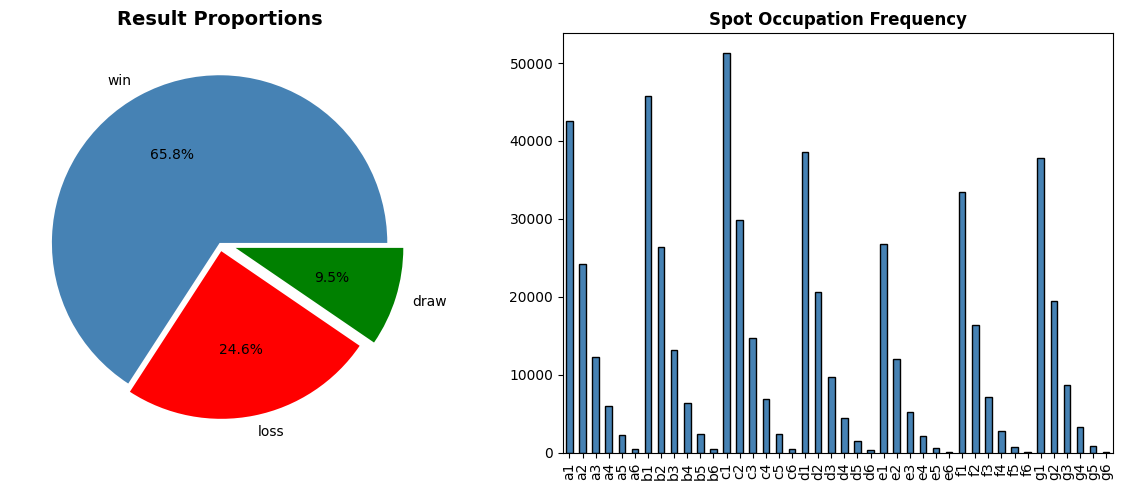

In [12]:
# read raw data
file = "./../data/raw/data.csv"

df = pd.read_csv(file)

print(f"Shape: {df.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'red', 'green']

df['class'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, explode=[0, 0.05, 0.1])
axes[0].set_title("Result Proportions", fontsize=14, fontweight='bold')
axes[0].set_ylabel("")

dup = df.copy()

(dup.drop(columns="class") != 'b').sum().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Spot Occupation Frequency", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Data Processing
* We need to convert the dataset from strings to numbers
* We do not need to scale the values, as they are always one of 3 discrete values

In [11]:
def string_to_numerical_value(val):
    # columns/rows
    if val == "b":
        return 0
    if val == "x":
        return 1
    if val == "o":
        return -1
    
    # win state (between 0 and 1 for sigmoid)
    if val == "win":
        return 1
    if val == "loss":
        return 0
    if val == "draw":
        return 0.5
    
    raise ValueError(f"Unknown value: {val}")

# process raw data into processed data

processed = df.copy()

# convert to numerical values
for col in processed.columns:
    processed[col] = processed[col].apply(string_to_numerical_value)

# write to processed
split = file.split('/') if '/' in file else file.split('\\')
out_file = '/'.join(split[:-1]) + "/../processed/data.csv"
print(f"output saved to {out_file}")
processed.to_csv(out_file, index=False)

output saved to ./../data/raw/../processed/data.csv


# Data Split
We want a relatively even split of wins and losses. Otherwise, the model will be >60% accurate by just selecting "win" every time.

output saved to ./../data/raw/../processed/evened.csv


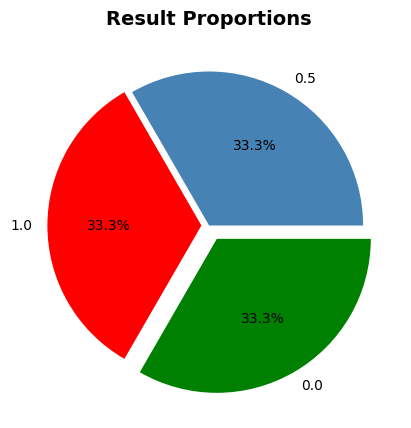

In [ ]:
wins = processed[processed["class"] == 1]
losses = processed[processed["class"] == 0]
evened = processed[processed["class"] == 0.5]

# since ties make up the smallest portion, we'll keep all of them and re-add an equal number of wins and losses
portion_size = len(evened)
evened = pd.concat([evened, wins.sample(n=portion_size)], ignore_index=True)
evened = pd.concat([evened, losses.sample(n=portion_size)], ignore_index=True)

# shuffle rows
evened = evened.sample(frac=1)

fig, axes = plt.subplots(1, 1, figsize=(12, 5))
colors = ['steelblue', 'red', 'green']

evened['class'].value_counts().plot(kind='pie', ax=axes, autopct='%1.1f%%', colors=colors, explode=[0, 0.05, 0.1])
axes.set_title("Result Proportions", fontsize=14, fontweight='bold')
axes.set_ylabel("")


# write to processed
split = file.split('/') if '/' in file else file.split('\\')
out_file = '/'.join(split[:-1]) + "/../processed/evened.csv"
print(f"output saved to {out_file}")
evened.to_csv(out_file, index=False)